In [19]:

import gc
import os
import sys
import time

import h5py
import mne
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from torchdiffeq import odeint, odeint_adjoint
import matplotlib.pyplot as plt

CONFIG = {

    "fif_path":  "/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif",
    "mat_path":  "/home/shobs/Desktop/DDP/scout_id_309.mat",
    "sc_path":   "/home/shobs/Desktop/DDP/SC_CC120309-27.mat",

    "ecg_channel_idx": 322,      # raw channel index for ECG (inverted)
    "target_eeg_idx":  11,        # which EEG region to model
    "fs_raw":          1000,     # raw sampling rate  [Hz]
    "fs_model":        100,      # model sampling rate [Hz]
    "train_sec":       10,       # seconds used for training
    "test_sec":        5,        # seconds used for testing
    "start_idx":       2000,     # sample offset into the recording

    # ── Preprocessing ─────────────────────────────────────────────────────────
    "ecg_lowcut":  1.5,          # ECG bandpass low  [Hz]
    "ecg_highcut": 20.0,         # ECG bandpass high [Hz]
    "eeg_lowcut":  0.5,          # EEG bandpass low  [Hz]
    "eeg_highcut": 20.0,         # EEG bandpass high [Hz]
    "butter_order": 4,

    # ── Structural connectivity ───────────────────────────────────────────────
    "sc_scale":       0.5,       # SC matrix normalisation scale
    "sc_percentile":  60,        # sparsity threshold percentile
    "sc_osc_scale":   10.0,      # after expanding to oscillator resolution

    # ── Brain oscillator layout ───────────────────────────────────────────────
    "osc_per_region":  4,        # oscillators per brain region
    "freq_low_hz":     1.0,      # random freq lower bound [Hz]
    "freq_high_hz":   20.0,      # random freq upper bound [Hz]
    "intra_coupling":  0.0001,   # intra-region coupling strength
    "brain_seed":      42,

    # ── Heart oscillator (Stuart-Landau) ─────────────────────────────────────
    "heart_alpha":      1.0,
    "heart_omega1":     7.6,    # [rad/s]
    "heart_omega2":     7.7,     # [rad/s]
    "heart_A_init":     0.0001,
    "heart_theta_init": 3.14159265358979,   # np.pi
    "heart_n":          1.0,
    "heart_mod_scale":  0.1,     # modulation strength on heart oscillator

    # ── HeartModel MLP ───────────────────────────────────────────────────────
    "heart_input_dim":   4,
    "heart_hidden_dim":  100,
    "heart_feature_dim": 50,
    "heart_output_dim":  1,
    "heart_dropout":     0.1,

    # ── Stage 1 – heart training ──────────────────────────────────────────────
    "heart_epochs":      20000,
    "heart_lr":          1e-3,
    "heart_sched_factor":  0.5,
    "heart_sched_patience": 500,
    "heart_log_every":   2500,

    # ── Brain ODE (TorchRevHopf) ─────────────────────────────────────────────
    "brain_mu": 1.0,

    # ── Stage 1 – brain pre-train ─────────────────────────────────────────────
    "brain_epochs":      100,    # ↑ from 300 for better convergence
    "brain_lr_omega":    1e-2,
    "brain_lr_alpha":    1e-2,
    "brain_lr_theta":    1e-3,
    "brain_sched_factor":  0.5,
    "brain_sched_patience": 20,
    "brain_settle":      10,     # warmup steps to ignore
    "brain_corr_weight":  1.0,   # weight for correlation loss
    "brain_scale_weight": 0.1,   # weight for scale matching loss
    "brain_alpha_pen":    0.2,   # weight for alpha-collapse penalty
    "brain_grad_clip":    1.0,
    "brain_log_every":   10,

    # ── ECGToOscillatorMLP ────────────────────────────────────────────────────
    "vns_n_osc":    18,          # oscillators on the VNS pathway
    "vns_hidden":   64,
    "vns_seed":     42,
    "vns_sparsity": 0.3,

    # ── Stage 2 – ECG→Brain training ─────────────────────────────────────────
    "stage2_epochs":      200,   # ↑ from 300
 
    "stage2_sched_threshold": 1e-3,
    "stage2_lr":              5e-3,    # bump back to v13
    "stage2_sched_patience":  40,      # was 15 — give it room to breathe
    "stage2_sched_factor":    0.5,     # was 0.3 — less aggressive drop
    "stage2_sched_cooldown":  10,      # was 5
    "stage2_min_lr":          1e-4, 
    "stage2_settle_frac": 0.1,  # fraction of steps to skip in loss
    "stage2_grad_clip":   1.0,
    "stage2_log_every":  10,
    "brain_eta_omega": 0.15,
    "brain_eta_alpha": 0.3,
    "brain_eta_theta": 0.05,
    "stage2_alpha_lr":  5e-3,    # separate LR for learnable alpha in Stage 2
    "stage2_alpha_reg": 0.01,  
    "stage2_hidden_noise": 0.01, 
    "stage2_eta_omega": 0.15,   # omega/theta don't conflict, keep same
    "stage2_eta_alpha": 0.0002, # only alpha needs to be neutered
    "stage2_eta_theta": 0.05,

    # ── BrainToHeartFeedbackMLP ───────────────────────────────────────────────
    "feedback_n_vns":  12,
    "feedback_hidden": 64,
    "feedback_seed":   99,

    # ── Stage 4 – feedback training ───────────────────────────────────────────
    "stage4_epochs":        40,   # ↑ from 100 for better ECG test score
    "stage4_lr":            1e-3,
    "stage4_sched_factor":  0.5,
    "stage4_sched_patience": 20,
    "stage4_min_lr":        1e-5,
    "stage4_grad_clip":     1.0,
    "stage4_log_every":     20,
    "ecg_feedback_highcut": 20.0, 
}

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20, order=4):
    """Detrend → bandpass → min-max normalise to [-1, 1]."""
    detrended = detrend(signal)
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    filtered = filtfilt(b, a, detrended)
    sig_min, sig_max = filtered.min(), filtered.max()
    denom = sig_max - sig_min
    if denom < 1e-10:          # flat signal guard
        return np.zeros_like(filtered)
    return 2.0 * (filtered - sig_min) / denom - 1.0


def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total = num_regions * osc_per_region
    return 2 * np.pi * np.random.uniform(low, high, total)


def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            si, ei = i * osc_per_region, (i + 1) * osc_per_region
            sj, ej = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[si:ei, sj:ej] = intra_value
            else:
                blk = np.random.rand(osc_per_region, osc_per_region)
                blk *= Sc_region[i, j] / (blk.sum() + 1e-9)
                Sc_full[si:ei, sj:ej] = blk
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full


def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()

class ZeroFeedback(nn.Module):
    def forward(self, x):
        T = x.shape[0] if x.dim() > 1 else 1
        return torch.zeros(T, 2, device=x.device)
# ──────────────────────────────────────────────────────────────────────────────
# Loss function
# ──────────────────────────────────────────────────────────────────────────────

class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        p = pred   - pred.mean()
        t = target - target.mean()
        num = (p * t).sum()
        den = torch.sqrt((p**2).sum() * (t**2).sum() + self.eps)
        return 1.0 - num / den


# ──────────────────────────────────────────────────────────────────────────────
# Heart sub-system
# ──────────────────────────────────────────────────────────────────────────────

class HeartModel(nn.Module):
    """MLP: oscillator states → ECG scalar."""

    def __init__(self, cfg):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(cfg["heart_input_dim"], cfg["heart_hidden_dim"]),
            nn.SiLU(),
            nn.Linear(cfg["heart_hidden_dim"], cfg["heart_hidden_dim"]),
            nn.SiLU(),
            nn.Dropout(cfg["heart_dropout"]),
            nn.Linear(cfg["heart_hidden_dim"], cfg["heart_feature_dim"]),
            nn.SiLU(),
        )
        self.output_layer = nn.Linear(cfg["heart_feature_dim"], cfg["heart_output_dim"])

    def forward(self, x):
        out = self.output_layer(self.feature_extractor(x))
        return torch.clamp(out, -1.0,1.0)

    def get_features(self, x):
        return self.feature_extractor(x)


class HeartOscillatorODEFunc(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.alpha      = cfg["heart_alpha"]
        self.A12        = cfg["heart_A_init"]
        self.A21        = cfg["heart_A_init"]
        self.n          = cfg["heart_n"]
        self.fs         = cfg["fs_model"]
        self.mod_scale  = cfg["heart_mod_scale"]
        self.omega1     = cfg["heart_omega1"]
        self.omega2     = cfg["heart_omega2"]
        self.modulation = None
        self.register_buffer("theta12", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))
        self.register_buffer("theta21", torch.tensor(cfg["heart_theta_init"], dtype=torch.float32))

    def forward(self, t, state):
        r1, phi1, r2, phi2 = state[0], state[1], state[2], state[3]
        r1 = torch.clamp(r1, 1e-6, 5.0)
        r2 = torch.clamp(r2, 1e-6, 5.0)

        c12 = self.A12 * r2 * torch.cos(self.theta12 + self.n * (phi2 - phi1))
        c21 = self.A21 * r1 * torch.cos(self.theta21 + self.n * (phi1 - phi2))

        if self.modulation is not None:
            t_idx = torch.clamp((t * self.fs).long(), 0, self.modulation.shape[0] - 1)
            mod = self.modulation[t_idx]
            dr1   = (self.alpha - r1**2) * r1 + c12 + self.mod_scale * mod[0]
            dr2   = (self.alpha - r2**2) * r2 + c21 + self.mod_scale * mod[1]
        else:
            dr1 = (self.alpha - r1**2) * r1 + c12
            dr2 = (self.alpha - r2**2) * r2 + c21

        dphi1 = self.omega1 + self.A12 * (r2 / r1) * torch.sin(self.theta12 + self.n * (phi2 - phi1))
        dphi2 = self.omega2 + self.A21 * (r1 / r2) * torch.sin(self.theta21 + self.n * (phi1 - phi2))
        return torch.stack([dr1, dphi1, dr2, dphi2])


class HeartOscillatorLayer(nn.Module):
    """Differentiable coupled Stuart-Landau heart oscillator via ODE."""

    def __init__(self, cfg, device="cpu"):
        super().__init__()
        self.fs     = cfg["fs_model"]
        self.device = device
        self.ode_func = HeartOscillatorODEFunc(cfg)
        self.register_buffer("y0", torch.tensor([1.0, 0.0, 1.0, 0.0], dtype=torch.float32))

    def forward(self, T, modulation=None):
        self.ode_func.modulation = modulation
        t_eval = torch.arange(0, T, dtype=torch.float32, device=self.y0.device) / self.fs
        sol = odeint(self.ode_func, self.y0, t_eval, method="rk4")   # (T, 4)
        r1  = torch.clamp(sol[:, 0], 1e-6, 5.0)
        phi1 = sol[:, 1]
        r2  = torch.clamp(sol[:, 2], 1e-6, 5.0)
        phi2 = sol[:, 3]
        return torch.stack([
            r1 * torch.cos(phi1),
            r1 * torch.sin(phi1),
            r2 * torch.cos(phi2),
            r2 * torch.sin(phi2),
        ], dim=1)


# ──────────────────────────────────────────────────────────────────────────────
# VNS oscillator sub-layer (shared by ECGToOscillatorMLP & BrainToHeartFeedbackMLP)
# ──────────────────────────────────────────────────────────────────────────────

class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta, fs=100):
        super().__init__()
        self.N_osc      = N_osc
        self.fs         = fs
        self.mu         = mu
        self.k          = k
        self.omega      = omega           # nn.Parameter
        self.register_buffer("C",     C)
        self.register_buffer("theta", theta)
        self.r_min      = 0.001
        self.r_max      = 3.0
        self.phase_clip = 2 * np.pi
        self.input_f    = None

    def forward(self, t, state):
        N   = self.N_osc
        r   = state[:N]
        phi = state[N:]

        t_idx   = torch.clamp((t * self.fs).long(), 0, self.input_f.shape[0] - 1)
        input_f = 0.05 * self.input_f[t_idx]

        omega   = torch.clamp(self.omega, 2 * np.pi * 1.0, 2 * np.pi * 20.0)
        r_safe  = torch.clamp(r, self.r_min, self.r_max)

        omega_i   = omega.unsqueeze(1);  omega_j  = omega.unsqueeze(0)
        phi_i     = phi.unsqueeze(1);    phi_j    = phi.unsqueeze(0)
        r_safe_i  = r_safe.unsqueeze(1); r_safe_j = r_safe.unsqueeze(0)

        phase_term = torch.clamp(
            phi_j / omega_j - phi_i / omega_i + self.theta / (omega_i * omega_j),
            -self.phase_clip, self.phase_clip,
        )
        coupling_r   = self.k * torch.sum(self.C * r_safe_j * torch.cos(phase_term), dim=1)
        coupling_phi = self.k * torch.sum(self.C * (r_safe_j / r_safe_i) * torch.sin(phase_term), dim=1)

        dr_dt   = (self.mu - r_safe**2) * r_safe + coupling_r   + input_f
        dphi_dt = omega + coupling_phi
        return torch.cat([dr_dt, dphi_dt])


class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, fs=100, device="cpu", coupling_sparsity=0.3, seed=42,freq_low=2.0, freq_high=10.0):
        super().__init__()
        self.N_osc = N_osc
        self.fs    = fs
        self.dt    = 1.0 / fs
        torch.manual_seed(seed)

        freqs = freq_low + torch.rand(N_osc, device=device) * (freq_high - freq_low)
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)
        self.register_buffer("mu_param", torch.tensor(1.0,  device=device))
        self.register_buffer("k_param",  torch.tensor(0.05, device=device))

        mask  = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)
        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.register_buffer("C_buffer",     C_val * mask.float())
        self.register_buffer("theta_buffer", torch.zeros(N_osc, N_osc, device=device))

        self.ode_func = OscillatorODEFunc(
            N_osc, self.mu_param, self.k_param, self.omega_param,
            self.C_buffer, self.theta_buffer, fs=fs,
        )
        self.register_buffer("initial_r",   torch.ones(N_osc, device=device) * 0.5)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))
        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features):   # (T, N_osc)
        T = input_features.shape[0]
        self.ode_func.input_f = input_features
        y0     = torch.cat([self.initial_r, self.initial_phi])
        t_eval = torch.arange(0, T, device=input_features.device, dtype=torch.float32) / self.fs
        sol    = odeint(self.ode_func, y0, t_eval, method="rk4")  # (T, 2N)
        r      = torch.clamp(sol[:, :self.N_osc], self.r_min, self.r_max)
        phi    = sol[:, self.N_osc:]
        return r * torch.cos(phi)


# ──────────────────────────────────────────────────────────────────────────────
# ECG → Brain drive MLP  (Stage 2)
# ──────────────────────────────────────────────────────────────────────────────

class ECGToOscillatorMLP(nn.Module):
    """ECG features → OscillatorLayer (VNS pathway) → Brain drive [N]"""

    def __init__(self, ecg_dim, N_VNS, hidden_dim, output_dim, device="cuda",
                 coupling_sparsity=0.3, seed=42):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.LayerNorm(ecg_dim),
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS),
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS, fs=100, device=device,
            coupling_sparsity=coupling_sparsity, seed=seed,freq_low=2.0, freq_high=10.0
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, ecg_features):   # (T, ecg_dim)
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)
        pre         = self.pre_osc(ecg_features)
        osc_hidden  = self.osc_layer(pre)
        brain_drive = self.post_osc(osc_hidden)
        return brain_drive.squeeze(0) if brain_drive.shape[0] == 1 else brain_drive


# ──────────────────────────────────────────────────────────────────────────────
# Brain → Heart feedback MLP  (Stage 4)
# ──────────────────────────────────────────────────────────────────────────────
from scipy.signal import welch

def hf_band_power_loss(pred, fs=100, low=10.0, high=20.0):
    """Penalize if high-frequency power in pred is less than target."""
    # Use a simple differentiable proxy: variance of high-pass filtered signal
    # Rather than welch (not differentiable), use the difference from smoothed version
    kernel_size = int(fs / low)  # samples per cycle at cutoff
    if kernel_size % 2 == 0:
        kernel_size += 1
    padding = kernel_size // 2
    smooth  = torch.nn.functional.avg_pool1d(
        pred.unsqueeze(0).unsqueeze(0), kernel_size, stride=1, padding=padding
    ).squeeze()[:pred.shape[0]]
    hf_component = pred - smooth
    return -hf_component.var() 

class BrainToHeartFeedbackMLP(nn.Module):
    """Brain r·cos(φ) → OscillatorLayer → 2 heart modulation channels."""

    def __init__(self, brain_dim, N_VNS=12, hidden_dim=64, device="cuda", seed=99):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.LayerNorm(brain_dim),
            nn.Linear(brain_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS),
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS, fs=100, device=device, coupling_sparsity=0.3, seed=seed,freq_low=10.0, freq_high=20.0
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, rcos_phi):   # (T, N_brain)
        if rcos_phi.dim() == 1:
            rcos_phi = rcos_phi.unsqueeze(0)
        pre        = self.pre_osc(rcos_phi)
        osc_hidden = self.osc_layer(pre)
        return self.post_osc(osc_hidden)


class ODEFuc(nn.Module):
    def __init__(self, mu, D_full, N, Sc, omega0, alpha0, theta0,
                 brain_drive_full=None, fs=100, fixed_params=None,
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0,learn_alpha=False):
        super().__init__()
        self.mu  = mu
        self.N   = N
        self.fs  = fs
        self.register_buffer("D_full", torch.tensor(D_full, dtype=torch.float32))
        self.register_buffer("Sc",     torch.tensor(Sc,     dtype=torch.float32))
        self.brain_drive_full = brain_drive_full
        self.fixed_params     = fixed_params
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.eta_theta = eta_theta
        self.learn_alpha = learn_alpha

        if fixed_params is not None:
            self.register_buffer("theta_fixed", torch.tensor(fixed_params["theta"], dtype=torch.float32))
            self.register_buffer("omega_fixed", torch.tensor(fixed_params["omega"], dtype=torch.float32))
            # alpha: learnable if learn_alpha=True, else frozen buffer
            if learn_alpha:
                self.alpha_param = nn.Parameter(
                    torch.tensor(fixed_params["alpha"], dtype=torch.float32)
                )
            else:
                self.register_buffer("alpha_fixed", torch.tensor(fixed_params["alpha"], dtype=torch.float32))
        else:
            self.omega_param = nn.Parameter(torch.tensor(omega0, dtype=torch.float32))
            self.alpha_param = nn.Parameter(torch.tensor(alpha0, dtype=torch.float32))
            self.theta_param = nn.Parameter(torch.tensor(theta0, dtype=torch.float32))
        self.t0 = 0.0

    def forward(self, t, state):
        N = self.N
        r   = state[:N]
        phi = state[N:2*N]
        phi = phi % (2 * np.pi) 
        has_adaptive = (self.eta_omega != 0.0 or self.eta_alpha != 0.0 or self.eta_theta != 0.0)

        if has_adaptive:
            theta = state[2*N:2*N+N**2].view(N, N)
            omega = state[2*N+N**2:3*N+N**2]
            alpha = state[3*N+N**2:4*N+N**2]
        elif self.fixed_params is not None:
            omega = self.omega_fixed
            theta = self.theta_fixed
            # alpha is either a learnable param or a frozen buffer
            alpha = self.alpha_param if self.learn_alpha else self.alpha_fixed
        else:
            omega = self.omega_param
            alpha = self.alpha_param
            theta = self.theta_param

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r          = torch.clamp(r, 1e-1, 2)
        alpha      = torch.clamp(alpha, -3.0, 3.0)

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]),
            -1e2, 1e2,
        )

        t_idx_D = torch.clamp(((t - self.t0) * self.fs).long(), 0, self.D_full.shape[0] - 1)
        D = self.D_full[t_idx_D]
        P = torch.sum(alpha * r * torch.cos(phi % (2 * np.pi)))
        e = D - P

        if self.brain_drive_full is not None:
            t_idx_drive = torch.clamp(((t - self.t0) * self.fs).long(), 0, self.brain_drive_full.shape[0] - 1)
            ecg_input   = self.brain_drive_full[t_idx_drive]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r   = torch.sum(self.Sc * r[None, :] * torch.cos(phase_diff), dim=1)
        coupling_phi = torch.sum(self.Sc * (r[None, :] / r[:, None]) * torch.sin(phase_diff), dim=1)

        drdt   = (self.mu - r**2) * r + coupling_r   + e * torch.cos(phi) + 0.7 * ecg_input
        dphidt = omega_safe          + coupling_phi - (e / r) * torch.sin(phi)

        if self.eta_omega != 0.0 or self.eta_alpha != 0.0 or self.eta_theta != 0.0:
            dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
            domegadt = -self.eta_omega * e * torch.sin(phi)
            dalphadt  = self.eta_alpha * e * r * torch.cos(phi)
            return torch.cat([drdt.flatten(), dphidt.flatten(),
                              dthetadt.flatten(), domegadt.flatten(), dalphadt.flatten()])
        
        return torch.cat([drdt.flatten(), dphidt.flatten()])


class TorchRevHopfNetwork:
    def __init__(self, mu, D_full, N, Sc,
                 omega0=None, alpha0=None, theta0=None,
                 brain_drive_full=None, fs=100,
                 fixed_params=None, device="cuda",
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0,
                 learn_alpha=False):          # ← new flag
        self.device = torch.device(device)
        self.N      = N
        self.ode_func = ODEFuc(
            mu=mu, D_full=D_full, N=N, Sc=Sc,
            omega0=omega0, alpha0=alpha0, theta0=theta0,
            brain_drive_full=brain_drive_full,
            fs=fs, fixed_params=fixed_params,
            eta_omega=eta_omega,
            eta_alpha=eta_alpha,
            eta_theta=eta_theta,
            learn_alpha=learn_alpha,          # ← pass through
        ).to(self.device)

    def solve(self, r0, phi0, t_eval, use_adjoint=False):
        N = self.N
        has_adaptive = (self.ode_func.eta_omega != 0.0 or 
                        self.ode_func.eta_alpha != 0.0 or 
                        self.ode_func.eta_theta != 0.0)
        
        if has_adaptive:
            theta0 = self.ode_func.theta_param.detach().cpu().numpy() if hasattr(self.ode_func,"theta_param") else np.zeros((N,N))
            omega0 = self.ode_func.omega_param.detach().cpu().numpy() if hasattr(self.ode_func,"omega_param") else np.ones(N)
            alpha0 = self.ode_func.alpha_param.detach().cpu().numpy() if hasattr(self.ode_func,"alpha_param") else np.ones(N)
            y0 = torch.tensor(
                np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
                device=self.device, dtype=torch.float32
            )
        else:
            y0 = torch.tensor(np.concatenate([r0, phi0]),
                            device=self.device, dtype=torch.float32)
        
        t_tensor = torch.tensor(t_eval, device=self.device, dtype=torch.float32)
        self.ode_func.t0 = t_tensor[0].item()
        sol = odeint(self.ode_func, y0, t_tensor, method="rk4")

        r   = sol[:, :N]
        phi = sol[:, N:2*N]

        if has_adaptive:
            theta = sol[:, 2*N:2*N+N**2].view(-1, N, N)
            omega = sol[:, 2*N+N**2:3*N+N**2]
            alpha = sol[:, 3*N+N**2:4*N+N**2]
        else:
            fp = self.ode_func.fixed_params
            if fp is not None:
                omega = self.ode_func.omega_fixed.unsqueeze(0).expand(sol.shape[0], N)
                alpha = (self.ode_func.alpha_param if self.ode_func.learn_alpha 
                        else self.ode_func.alpha_fixed).unsqueeze(0).expand(sol.shape[0], N)
                theta = self.ode_func.theta_fixed.unsqueeze(0).expand(sol.shape[0], N, N)
            else:
                omega = self.ode_func.omega_param.unsqueeze(0).expand(sol.shape[0], N)
                alpha = self.ode_func.alpha_param.unsqueeze(0).expand(sol.shape[0], N)
                theta = self.ode_func.theta_param.unsqueeze(0).expand(sol.shape[0], N, N)

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)
        return r, phi, theta, omega, alpha, rcos_phi

def train_heart_model(ecg_signal, cfg, device):
    """Stage 1a – train HeartModel MLP to reconstruct ECG from oscillator states."""
    print("\n--- Stage 1: Heart Model Training ---")
    model          = HeartModel(cfg).to(device)
    heart_osc_layer = HeartOscillatorLayer(cfg, device=device).to(device)
    heart_osc_layer.y0 = torch.tensor(
        [1.0, 0.0, 1.0, np.pi/2],
        dtype=torch.float32, device=device
    )
    optimizer = optim.Adam(model.parameters(), lr=cfg["heart_lr"])
    scheduler      = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=cfg["heart_sched_factor"],
        patience=cfg["heart_sched_patience"],
    )
    def weighted_mse(pred, target):
        weights = 1.0 + 4.0 * (target.abs() > 0.7).float() 
        return torch.mean(weights * (pred - target)**2)
    T_train    = int(cfg["train_sec"] * cfg["fs_model"])
    target     = torch.tensor(
        ecg_signal[::10], dtype=torch.float32
    ).unsqueeze(1).to(device)

    with torch.no_grad():
        sim_input = heart_osc_layer(T_train, modulation=None)

    losses = []
    for epoch in range(cfg["heart_epochs"]):
        pred = model(sim_input)
        loss = weighted_mse(pred,target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())
        if (epoch + 1) % cfg["heart_log_every"] == 0:
            print(f"  Epoch {epoch+1:5d}  Loss: {loss.item():.6f}")

    return model, heart_osc_layer, losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx,
                          non_zero_indices_per_row, t, D_function,
                          cfg, device):
    print("\n--- Stage 1b: Brain Pre-training (forward roll, no backprop) ---")

    connected_indices   = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions   = len(connected_indices)
    osc_per_region      = cfg["osc_per_region"]
    N                   = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc      = expand_structural_connectivity(
        Sc_reduced_regional, osc_per_region,
        intra_value=cfg["intra_coupling"], seed=cfg["brain_seed"],
    )
    Sc_reduced_osc     *= cfg["sc_osc_scale"]
    print(f"  N={N}  N_regions={N_reduced_regions}  "
          f"SC sparsity={(Sc_reduced_osc == 0).mean():.3f}  "
          f"SC max={Sc_reduced_osc.max():.4f}")

    omega_full = get_random_frequencies(
        68, osc_per_region,
        low=cfg["freq_low_hz"], high=cfg["freq_high_hz"],
        seed=cfg["brain_seed"],
    )
    omega0 = np.concatenate([
        omega_full[i * osc_per_region:(i + 1) * osc_per_region]
        for i in connected_indices
    ])

    alpha0 = np.ones(N) * (1.0 / np.sqrt(N))
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0       = theta_random - theta_random.T
    r0           = np.ones(N)
    phi0         = np.zeros(N)

    D_full_train = D_function(t)
    D_true       = torch.tensor(D_full_train, device=device, dtype=torch.float32)

    model = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc,
        omega0=omega0, alpha0=alpha0, theta0=theta0,
        fs=cfg["fs_model"], fixed_params=None, device=device,
        eta_omega=cfg["brain_eta_omega"],
        eta_alpha=cfg["brain_eta_alpha"],
        eta_theta=cfg["brain_eta_theta"],
    )

    # ── Initial sign alignment ─────────────────────────────────────────────
    with torch.no_grad():
        r_init, phi_init, _, _, alpha_init, _ = model.solve(
            r0, phi0, t, use_adjoint=False
        )
        P_init    = torch.sum(alpha_init * r_init * torch.cos(phi_init), dim=1)
        p0        = P_init - P_init.mean()
        d0        = D_true - D_true.mean()
        sign_corr = torch.sign((p0 * d0).sum())
        if sign_corr < 0:
            alpha0 = -alpha0
            model.ode_func.alpha_param.data = torch.tensor(
                alpha0, dtype=torch.float32, device=device)
        print(f"  Alpha sign flip applied: {sign_corr.item() < 0}")

    best_loss        = float("inf")
    best_state       = dict(r=r0.copy(), phi=phi0.copy(),
                            theta=theta0.copy(), omega=omega0.copy(),
                            alpha=alpha0.copy())
    patience_counter = 0
    revert_patience  = 30
    losses           = []
    epochs           = cfg["brain_epochs"]

    for epoch in range(epochs):
        with torch.no_grad():
            r, phi, theta, omega, alpha, _ = model.solve(
                r0, phi0, t, use_adjoint=False
            )
            P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)

            settle    = cfg["brain_settle"]
            pred      = P_out[settle:]
            tgt       = D_true[settle:]
            pred_norm = (pred - pred.mean()) / (pred.std() + 1e-8)
            tgt_norm  = (tgt  - tgt.mean())  / (tgt.std()  + 1e-8)

            mse_loss  = torch.mean((pred_norm - tgt_norm) ** 2)
            corr_loss = CorrelationLoss()(pred, tgt)
            loss      = mse_loss + 0.3 * corr_loss
            loss_val  = loss.item()
            losses.append(loss_val)

            if loss_val < best_loss:
                best_loss = loss_val
                # ── FIX: enforce sign on alpha before saving to best_state ──
                alpha_end = alpha[-1].cpu().numpy().copy()
                p_end     = P_out.cpu().numpy()
                d_end     = D_full_train
                sign      = np.sign(np.dot(p_end - p_end.mean(),
                                           d_end  - d_end.mean()))
                if sign < 0:
                    alpha_end = -alpha_end
                best_state = dict(
                    r=r[-1].cpu().numpy().copy(),
                    phi=(phi[-1].cpu().numpy() % (2 * np.pi)).copy(),
                    theta=theta[-1].cpu().numpy().copy(),
                    omega=omega[-1].cpu().numpy().copy(),
                    alpha=alpha_end,           # ← sign-corrected
                )
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= revert_patience:
                r0     = best_state["r"].copy()
                phi0   = best_state["phi"].copy()
                theta0 = best_state["theta"].copy()
                omega0 = best_state["omega"].copy()
                alpha0 = best_state["alpha"].copy()
                model.ode_func.omega_param.data = torch.tensor(
                    omega0, dtype=torch.float32, device=device)
                model.ode_func.alpha_param.data = torch.tensor(
                    alpha0, dtype=torch.float32, device=device)
                model.ode_func.theta_param.data = torch.tensor(
                    theta0, dtype=torch.float32, device=device)
                patience_counter = 0
                if (epoch + 1) % cfg["brain_log_every"] == 0:
                    print(f"    [revert to best @ epoch {epoch+1}]")
            else:
                r0     = r[-1].cpu().numpy()
                phi0   = phi[-1].cpu().numpy() % (2 * np.pi)
                theta0 = theta[-1].cpu().numpy()
                omega0 = omega[-1].cpu().numpy()
                # ── FIX: enforce sign on alpha before feeding forward ───────
                alpha_np = alpha[-1].cpu().numpy()
                p_cur    = P_out.cpu().numpy()
                sign_cur = np.sign(np.dot(p_cur - p_cur.mean(),
                                          D_full_train - D_full_train.mean()))
                if sign_cur < 0:
                    alpha_np = -alpha_np
                alpha0 = alpha_np
                model.ode_func.omega_param.data = omega[-1].flatten()
                model.ode_func.alpha_param.data = torch.tensor(
                    alpha0, dtype=torch.float32, device=device)
                model.ode_func.theta_param.data = theta[-1]

            perturb_every = max(10, 30 - epoch // 10)
            if (epoch + 1) % perturb_every == 0:
                sigma = 0.15 * (1.0 - epoch / epochs)
                r0    = np.clip(r0   + sigma * np.random.randn(N), 0.1, 4.0)
                phi0  = (phi0 + sigma * np.random.randn(N)) % (2 * np.pi)

        if (epoch + 1) % cfg["brain_log_every"] == 0:
            print(f"  Brain Epoch {epoch+1:3d}/{epochs}  "
                  f"Loss: {loss_val:.6f}  "
                  f"P_std: {P_out.std().item():.4f}  "
                  f"D_std: {D_true.std().item():.4f}  "
                  f"best: {best_loss:.6f}")

    # ── FIX: final sign check on best_state before returning ──────────────
    with torch.no_grad():
        model.ode_func.alpha_param.data = torch.tensor(
            best_state["alpha"], dtype=torch.float32, device=device)
        r_f, phi_f, _, _, alpha_f, _ = model.solve(
            best_state["r"], best_state["phi"], t, use_adjoint=False)
        P_f   = torch.sum(alpha_f * r_f * torch.cos(phi_f), dim=1)
        p_f   = P_f.cpu().numpy()
        sign_f = np.sign(np.dot(p_f - p_f.mean(), D_full_train - D_full_train.mean()))
        if sign_f < 0:
            best_state["alpha"] = -best_state["alpha"]
        print(f"  Final sign check: {'flipped' if sign_f < 0 else 'ok'}")

    final_params = {
        "r":     best_state["r"],
        "phi":   best_state["phi"],
        "theta": best_state["theta"],
        "omega": best_state["omega"],
        "alpha": best_state["alpha"],
    }

    return final_params, Sc_reduced_osc, N, losses


def train_feedback_stage(trained_heart_model, trained_mlp_model,
                          heart_osc_layer, final_brain_params,
                          Sc_reduced_osc, N, D_full_func,
                          t_train, ecg_train_processed, cfg, device):
    print("\n--- Stage 4: Brain→Heart Feedback Training ---")

    feedback_mlp = BrainToHeartFeedbackMLP(
        brain_dim=N,
        N_VNS=cfg["feedback_n_vns"],
        hidden_dim=cfg["feedback_hidden"],
        device=device,
        seed=cfg["feedback_seed"],
    ).to(device)

    optimizer = torch.optim.Adam(
        list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
        lr=cfg["stage4_lr"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["stage4_sched_factor"],
        patience=cfg["stage4_sched_patience"],
        min_lr=cfg["stage4_min_lr"],
    )
    criterion  = CorrelationLoss()
    T_train    = len(t_train)
    target_ecg = torch.tensor(
        ecg_train_processed[::10], dtype=torch.float32, device=device
    ).unsqueeze(1)
    D_full_train = D_full_func(t_train)
    losses = []

    # ── Precompute everything frozen ──────────────────────────────────────
    # In train_feedback_stage, replace the precompute block:

    with torch.no_grad():
        sim_plain   = heart_osc_layer(T_train, modulation=None).detach()
        hidden_base = trained_heart_model.get_features(sim_plain).detach()
        brain_drive = trained_mlp_model(hidden_base)
        brain_drive = torch.clamp(brain_drive, -5.0, 5.0).detach()

        model_brain = TorchRevHopfNetwork(
            mu=cfg["brain_mu"], D_full=D_full_train, N=N,
            Sc=Sc_reduced_osc, brain_drive_full=brain_drive,
            fs=cfg["fs_model"], fixed_params=final_brain_params,
            device=device, learn_alpha=False,
        )
        r_br, phi_br, _, _, _, _ = model_brain.solve(
            final_brain_params["r"], final_brain_params["phi"],
            t_train, use_adjoint=False,
        )
        rcos_phi      = (r_br * torch.cos(phi_br)).detach()
        base_features = trained_heart_model.get_features(sim_plain).detach()

    # ── Jacobian computed OUTSIDE no_grad ────────────────────────────────
    # sim_plain is a plain tensor — requires_grad_(True) makes it a leaf
    # that autograd can differentiate through the feature extractor
    sim_plain_for_jac = sim_plain.clone().requires_grad_(True)
    feats_for_jac     = trained_heart_model.get_features(sim_plain_for_jac)

    jac = torch.zeros(T_train, feats_for_jac.shape[1], 4, device=device)
    for f in range(feats_for_jac.shape[1]):
        g = torch.autograd.grad(
            feats_for_jac[:, f].sum(), sim_plain_for_jac,
            retain_graph=True, create_graph=False
        )[0]
        jac[:, f, :] = g

    jac = jac.detach()  # detach after — don't need graph beyond this point

    mod_scale = cfg["heart_mod_scale"]

    print(f"  rcos_phi shape: {rcos_phi.shape}  "
          f"Jacobian computed: {jac.shape}")

    # ── Training loop — NO ODE solve inside ──────────────────────────────
    for epoch in range(cfg["stage4_epochs"]):
        modulation = feedback_mlp(rcos_phi)   # (T, 2)

        # Linear approximation: perturbed features ≈ base + J · δ
        # delta_osc: (T, 4) — modulation affects channels 0 and 1 via mod_scale
        delta_osc = torch.zeros(T_train, 4, device=device)
        delta_osc[:, 0] = mod_scale * modulation[:, 0]
        delta_osc[:, 1] = mod_scale * modulation[:, 1]

        # delta_features: (T, F)
        delta_features = torch.einsum("tfi,ti->tf", jac, delta_osc)
        perturbed_features = base_features + delta_features

        # ECG prediction from perturbed features
        pred_ecg = trained_heart_model.output_layer(perturbed_features)
        pred_ecg = torch.clamp(pred_ecg, -1.0, 1.0)

        corr_loss  = criterion(pred_ecg.squeeze(), target_ecg.squeeze())
        scale_loss = (pred_ecg.squeeze().std() / (target_ecg.squeeze().std() + 1e-8) - 1.0) ** 2
        hf_loss    = hf_band_power_loss(pred_ecg.squeeze())
        loss       = corr_loss + 0.5 * scale_loss + 0.3 * hf_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
            max_norm=cfg["stage4_grad_clip"],
        )
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())

        if (epoch + 1) % cfg["stage4_log_every"] == 0:
            lr       = optimizer.param_groups[0]["lr"]
            mod_mean = modulation.abs().mean().item()
            print(f"  Feedback Epoch {epoch+1:3d}/{cfg['stage4_epochs']}  "
                  f"Loss: {loss.item():.6f}  mod_mean: {mod_mean:.4f}  LR: {lr:.3e}")

        # ── Periodic ODE re-linearisation (every 20 epochs) ──────────────
        # The Jacobian is only valid near the base trajectory. Re-linearise
        # once the modulation has grown large enough to shift the trajectory.
        if (epoch + 1) % 20 == 0:
            with torch.no_grad():
                avg_mod = modulation.abs().mean().item()
            if avg_mod > 0.05:
                with torch.no_grad():
                    sim_mod       = heart_osc_layer(T_train, modulation=modulation.detach())
                    base_features = trained_heart_model.get_features(sim_mod).detach()

                # ── outside no_grad for the same reason ──────────────────────
                sim_for_jac = sim_mod.detach().clone().requires_grad_(True)
                feats_jac   = trained_heart_model.get_features(sim_for_jac)
                jac         = torch.zeros(T_train, feats_jac.shape[1], 4, device=device)
                for f in range(feats_jac.shape[1]):
                    g = torch.autograd.grad(
                        feats_jac[:, f].sum(), sim_for_jac,
                        retain_graph=True, create_graph=False
                    )[0]
                    jac[:, f, :] = g
                jac = jac.detach()

    print("--- Stage 4 Finished ---")
    return feedback_mlp, losses

def train_mlp_on_frozen_brain(trained_heart_model, heart_osc_layer,
                               initial_brain_params, Sc_reduced_osc,
                               N, D_function, t, cfg, device, t_sec):
    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training (alpha learnable) ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=cfg["heart_feature_dim"],
        N_VNS=cfg["vns_n_osc"],
        hidden_dim=cfg["vns_hidden"],
        output_dim=N,
        device=device,
        coupling_sparsity=cfg["vns_sparsity"],
        seed=cfg["vns_seed"],
    ).to(device)

    D_full_train = D_function(t)
    D_true       = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    settle       = int(cfg["stage2_settle_frac"] * cfg["fs_model"])
    T_steps      = int(t_sec * cfg["fs_model"])

    model = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_full_train, N=N,
        Sc=Sc_reduced_osc, brain_drive_full=None,
        fs=cfg["fs_model"], fixed_params=initial_brain_params,
        device=device, learn_alpha=True,
        eta_omega=cfg.get("stage2_eta_omega", cfg["brain_eta_omega"]),
        eta_alpha=cfg.get("stage2_eta_alpha", 0.0002),
        eta_theta=cfg.get("stage2_eta_theta", cfg["brain_eta_theta"]),
    )

    # ── FIX 1: alpha sign alignment before any training ───────────────────
    with torch.no_grad():
        r_check, phi_check, _, _, alpha_check, _ = model.solve(
            initial_brain_params["r"], initial_brain_params["phi"],
            t, use_adjoint=False,
        )
        P_check = torch.sum(alpha_check * r_check * torch.cos(phi_check), dim=1)
        p0 = P_check - P_check.mean()
        d0 = D_true  - D_true.mean()
        if (p0 * d0).sum() < 0:
            model.ode_func.alpha_param.data *= -1.0
            print("  [Stage 2] alpha sign corrected at init")

    optimizer = torch.optim.Adam([
        {"params": ecg_to_osc_mlp.parameters(),   "lr": cfg["stage2_lr"]},
        {"params": [model.ode_func.alpha_param],   "lr": cfg.get("stage2_alpha_lr", 1e-3)},
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=cfg["stage2_sched_factor"],
        patience=cfg["stage2_sched_patience"],
        threshold=cfg["stage2_sched_threshold"],
        cooldown=cfg["stage2_sched_cooldown"],
        min_lr=cfg["stage2_min_lr"],
    )
    criterion        = CorrelationLoss()
    alpha_reg_weight = cfg.get("stage2_alpha_reg", 0.1)
    noise_scale      = cfg.get("stage2_hidden_noise", 0.01)
    losses           = []

    # ── FIX 2: precompute outside loop but keep as detached tensor ────────
    # hidden_repr must NOT carry grad from heart_osc_layer into the loop
    with torch.no_grad():
        sim_input   = heart_osc_layer(T_steps, modulation=None)
        hidden_repr = trained_heart_model.get_features(sim_input).detach()


    r0_fixed   = initial_brain_params["r"].copy()
    phi0_fixed = initial_brain_params["phi"].copy()

    for epoch in range(cfg["stage2_epochs"]):
        hidden_noisy = hidden_repr + noise_scale * torch.randn_like(hidden_repr)
        raw_drive    = ecg_to_osc_mlp(hidden_noisy)
        brain_drive  = torch.clamp(raw_drive, -5.0, 5.0)
        model.ode_func.brain_drive_full = brain_drive

        r, phi, theta, omega, alpha, _ = model.solve(
            r0_fixed, phi0_fixed,   # ← FIX 3: always same start, never mutated
            t, use_adjoint=False,
        )
        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        pred  = P_out[settle:]
        tgt   = D_true[settle:]

        # v13 loss — this is what was working
        P_norm     = pred * (tgt.std() / (pred.std() + 1e-8))
        mse_loss   = torch.mean((P_norm - tgt) ** 2)
        corr_loss  = criterion(pred, tgt)
        scale_loss = (pred.std() / (tgt.std() + 1e-8) - 1.0) ** 2
        alpha_pen  = torch.mean(torch.relu(0.1 - model.ode_func.alpha_param ** 2))
        loss = mse_loss + 0.3 * corr_loss + 0.5 * scale_loss + alpha_reg_weight * alpha_pen
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(ecg_to_osc_mlp.parameters()) + [model.ode_func.alpha_param],
            max_norm=cfg["stage2_grad_clip"],
        )
        optimizer.step()

        with torch.no_grad():
            model.ode_func.alpha_param.clamp_(-3.0, 3.0)

        scheduler.step(loss.item())
        losses.append(loss.item())

        if (epoch + 1) % cfg["stage2_log_every"] == 0:
            lr        = optimizer.param_groups[0]["lr"]
            alpha_std = model.ode_func.alpha_param.std().item()
            print(f"  Epoch {epoch+1:3d}/{cfg['stage2_epochs']}  "
                  f"Loss: {loss.item():.6f}  "
                  f"α_std: {alpha_std:.4f}  "
                  f"LR: {lr:.3e}")

    refined_alpha = model.ode_func.alpha_param.detach().cpu().numpy()
    return ecg_to_osc_mlp, losses, refined_alpha

@torch.no_grad()
def evaluate_full(trained_heart_model, heart_osc_layer,
                  trained_mlp_model, feedback_mlp,
                  final_brain_params, Sc_reduced_osc, N,
                  D_ode_func, D_metric_func,
                  t_full, t_train, t_test,        # ← add t_train, t_test
                  ecg_full_processed, cfg, device):

    T_full  = len(t_full)
    T_train = int(cfg["train_sec"] * cfg["fs_model"])
    D_metric = D_metric_func(t_full)
    D_true_t = torch.tensor(D_metric, device=device, dtype=torch.float32)
    ecg_target_t = torch.tensor(
        ecg_full_processed[::10], dtype=torch.float32, device=device
    ).unsqueeze(1)

    sim_plain   = heart_osc_layer(T_full, modulation=None)
    hidden      = trained_heart_model.get_features(sim_plain)
    brain_drive = trained_mlp_model(hidden)
    brain_drive = torch.clamp(brain_drive, -5.0, 5.0)

    # ── Two-segment brain ODE solve ───────────────────────────────────────
    D_train_arr = D_ode_func(t_train)
    model_tr = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_train_arr, N=N,
        Sc=Sc_reduced_osc, brain_drive_full=brain_drive[:T_train],
        fs=cfg["fs_model"], fixed_params=final_brain_params,
        device=device, learn_alpha=False,
    )
    r_tr, phi_tr, _, _, alpha_tr, _ = model_tr.solve(
        final_brain_params["r"], final_brain_params["phi"],
        t_train, use_adjoint=False,
    )

    D_test_arr = D_metric_func(t_test)   # true EEG for test forcing
    model_te = TorchRevHopfNetwork(
        mu=cfg["brain_mu"], D_full=D_test_arr, N=N,
        Sc=Sc_reduced_osc, brain_drive_full=brain_drive[T_train:],
        fs=cfg["fs_model"], fixed_params=final_brain_params,
        device=device, learn_alpha=False,
    )
    r_te, phi_te, _, _, alpha_te, _ = model_te.solve(
        r_tr[-1].cpu().numpy(), phi_tr[-1].cpu().numpy(),
        t_test, use_adjoint=False,
    )

    r_br   = torch.cat([r_tr,     r_te],     dim=0)
    phi_br = torch.cat([phi_tr,   phi_te],   dim=0)
    alpha  = torch.cat([alpha_tr, alpha_te], dim=0)

    rcos_phi      = r_br * torch.cos(phi_br)
    modulation    = feedback_mlp(rcos_phi)
    sim_modulated = heart_osc_layer(T_full, modulation=modulation)
    pred_ecg      = trained_heart_model(sim_modulated)

    P_out  = torch.sum(alpha * r_br * torch.cos(phi_br), dim=1)
    scale  = D_true_t[:T_train].std() / (P_out[:T_train].std() + 1e-8)
    P_out  = P_out * scale

    settle = int(cfg["stage2_settle_frac"] * cfg["fs_model"])

    def calc_metrics(pred, target):
        mse       = torch.mean((pred - target) ** 2).item()
        mae       = torch.mean(torch.abs(pred - target)).item()
        p0        = pred   - pred.mean()
        t0        = target - target.mean()
        corr      = (p0 * t0).sum() / (torch.sqrt((p0**2).sum() * (t0**2).sum()) + 1e-8)
        std_ratio = (pred.std() / (target.std() + 1e-8)).item()
        return mse, mae, corr.item(), std_ratio

    train_slice = slice(settle, T_train)
    test_slice  = slice(T_train, T_full)

    ecg_mse_tr, ecg_mae_tr, ecg_corr_tr, ecg_amp_tr = calc_metrics(
        pred_ecg.squeeze()[train_slice], ecg_target_t.squeeze()[train_slice])
    eeg_mse_tr, eeg_mae_tr, eeg_corr_tr, eeg_amp_tr = calc_metrics(
        P_out[train_slice], D_true_t[train_slice])
    ecg_mse_te, ecg_mae_te, ecg_corr_te, ecg_amp_te = calc_metrics(
        pred_ecg.squeeze()[test_slice], ecg_target_t.squeeze()[test_slice])
    eeg_mse_te, eeg_mae_te, eeg_corr_te, eeg_amp_te = calc_metrics(
        P_out[test_slice], D_true_t[test_slice])

    print(f"\nECG Train | MSE: {ecg_mse_tr:.4f} | MAE: {ecg_mae_tr:.4f} | Corr: {ecg_corr_tr:.4f} | Amp: {ecg_amp_tr:.4f}")
    print(f"ECG Test  | MSE: {ecg_mse_te:.4f} | MAE: {ecg_mae_te:.4f} | Corr: {ecg_corr_te:.4f} | Amp: {ecg_amp_te:.4f}")
    print(f"\nEEG Train | MSE: {eeg_mse_tr:.4f} | MAE: {eeg_mae_tr:.4f} | Corr: {eeg_corr_tr:.4f} | Amp: {eeg_amp_tr:.4f}")
    print(f"EEG Test  | MSE: {eeg_mse_te:.4f} | MAE: {eeg_mae_te:.4f} | Corr: {eeg_corr_te:.4f} | Amp: {eeg_amp_te:.4f}")


def save_with_splits(arr, name, region_dir, T_train):
    np.save(f"{region_dir}/{name}_full.npy", arr)
    np.save(f"{region_dir}/{name}_train.npy", arr[:T_train])
    np.save(f"{region_dir}/{name}_test.npy", arr[T_train:])

def run_pipeline_for_region(
    region_idx,
    cfg,
    raw,
    mat,
    Sw_all,
    non_zero_indices_per_row,
    ecg_full_processed,
    ecg_full_processed_fb,
    eeg_full_processed,
    t_full,
    t_train,
    t_test,
    D_full_func,
    device,
    save_root
):
    print(f"\n================ REGION {region_idx} ================\n")

    cfg_local = cfg.copy()
    cfg_local["target_eeg_idx"] = region_idx

    region_dir = os.path.join(save_root, f"region_{region_idx}")
    os.makedirs(region_dir, exist_ok=True)

    fs_model = cfg["fs_model"]
    train_sec = cfg["train_sec"]
    T_train = int(train_sec * fs_model)

    # ─────────────────────────────
    # Ground truth
    # ─────────────────────────────
    true_ecg = ecg_full_processed_fb[::10]
    true_eeg = eeg_full_processed[region_idx, ::10]

    # ─────────────────────────────
    # Stage 1a – Heart
    # ─────────────────────────────
    ecg_train = ecg_full_processed[:train_sec * cfg["fs_raw"]]

    trained_heart_model, heart_osc_layer, heart_losses = train_heart_model(
        ecg_train, cfg_local, device
    )

    # ─────────────────────────────
    # Stage 1b – Brain
    # ─────────────────────────────
    initial_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
        eeg_full_processed[:, :train_sec * cfg["fs_raw"]],
        Sw_all,
        region_idx,
        non_zero_indices_per_row,
        t_train,
        lambda t: D_full_func(t),
        cfg_local,
        device,
    )

    # ===== Stage 1b EEG (FULL) =====
    with torch.no_grad():
        model_s1b = TorchRevHopfNetwork(
            mu=cfg["brain_mu"],
            D_full=D_full_func(t_full),
            N=N,
            Sc=Sc_reduced_osc,
            fs=cfg["fs_model"],
            fixed_params=initial_brain_params,
            device=device,
            learn_alpha=False,
        )

        r1, phi1, _, _, alpha1, _ = model_s1b.solve(
            initial_brain_params["r"],
            initial_brain_params["phi"],
            t_full,
            use_adjoint=False,
        )

        eeg_stage1b = torch.sum(alpha1 * r1 * torch.cos(phi1), dim=1).cpu().numpy()

    # ─────────────────────────────
    # Stage 2 – ECG → Brain
    # ─────────────────────────────
    trained_mlp, stage2_losses, refined_alpha = train_mlp_on_frozen_brain(
        trained_heart_model,
        heart_osc_layer,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_full_func,
        t_train,
        cfg_local,
        device,
        t_sec=train_sec,
    )

    final_brain_params = {**initial_brain_params, "alpha": refined_alpha}

    # ===== Stage 2 outputs (FULL) =====
    with torch.no_grad():
        T_full_len = len(t_full)

        sim_plain = heart_osc_layer(T_full_len, modulation=None)
        hidden = trained_heart_model.get_features(sim_plain)

        brain_drive = trained_mlp(hidden)
        brain_drive = torch.clamp(brain_drive, -5.0, 5.0)

        model_s2 = TorchRevHopfNetwork(
            mu=cfg["brain_mu"],
            D_full=D_full_func(t_full),
            N=N,
            Sc=Sc_reduced_osc,
            brain_drive_full=brain_drive,
            fs=cfg["fs_model"],
            fixed_params=final_brain_params,
            device=device,
            learn_alpha=False,
        )

        r2, phi2, _, _, alpha2, _ = model_s2.solve(
            final_brain_params["r"],
            final_brain_params["phi"],
            t_full,
            use_adjoint=False,
        )

        eeg_stage2 = torch.sum(alpha2 * r2 * torch.cos(phi2), dim=1).cpu().numpy()
        ecg_stage2 = trained_heart_model(sim_plain).squeeze().cpu().numpy()

    # ─────────────────────────────
    # Stage 4 – Feedback
    # ─────────────────────────────
    feedback_mlp, stage4_losses = train_feedback_stage(
        trained_heart_model,
        trained_mlp,
        heart_osc_layer,
        final_brain_params,
        Sc_reduced_osc,
        N,
        D_full_func,
        t_train,
        ecg_full_processed_fb[:train_sec * cfg["fs_raw"]],
        cfg_local,
        device,
    )

    # ===== Stage 4 ECG (FULL) =====
    with torch.no_grad():
        rcos_phi = r2 * torch.cos(phi2)
        modulation = feedback_mlp(rcos_phi)
        sim_modulated = heart_osc_layer(len(t_full), modulation=modulation)
        ecg_stage4 = trained_heart_model(sim_modulated).squeeze().cpu().numpy()

    # ─────────────────────────────
    # SAVE EVERYTHING
    # ─────────────────────────────

    # Ground truth
    save_with_splits(true_ecg, "ecg_true", region_dir, T_train)
    save_with_splits(true_eeg, "eeg_true", region_dir, T_train)

    # Stage 1b
    save_with_splits(eeg_stage1b, "eeg_stage1b", region_dir, T_train)

    # Stage 2
    save_with_splits(eeg_stage2, "eeg_stage2", region_dir, T_train)
    save_with_splits(ecg_stage2, "ecg_stage2", region_dir, T_train)

    # Stage 4
    save_with_splits(ecg_stage4, "ecg_stage4", region_dir, T_train)

    # Losses
    np.save(f"{region_dir}/loss_heart.npy", heart_losses)
    np.save(f"{region_dir}/loss_brain.npy", brain_losses)
    np.save(f"{region_dir}/loss_stage2.npy", stage2_losses)
    np.save(f"{region_dir}/loss_stage4.npy", stage4_losses)

    # ─────────────────────────────
    # Save training curves
    # ─────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))

    axes[0].plot(heart_losses);  axes[0].set_title("Heart")
    axes[1].plot(brain_losses);  axes[1].set_title("Brain")
    axes[2].plot(stage2_losses); axes[2].set_title("Stage 2")
    axes[3].plot(stage4_losses); axes[3].set_title("Stage 4")

    for ax in axes:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{region_dir}/training_curves.png")
    plt.close()

    print(f"Saved outputs for region {region_idx}")

In [20]:
save_root = "/home/shobs/Desktop/DDP/multi_region_results"
os.makedirs(save_root, exist_ok=True)
cfg    = CONFIG
device = "cuda" if torch.cuda.is_available() else "cpu"
# device="cpu"
print(f"--- Device: {device} ---")

# ── Load raw data ────────────────────────────────────────────────────────
raw      = mne.io.read_raw_fif(cfg["fif_path"], preload=True)
mat      = loadmat(cfg["mat_path"])
sc_data  = loadmat(cfg["sc_path"])
sc_matrix = sc_data["sc"]

# Structural connectivity
max_val   = np.max(sc_matrix)
Sw_all    = (sc_matrix / max_val) * cfg["sc_scale"]
thr       = np.percentile(Sw_all, cfg["sc_percentile"])
Sw_sparse = Sw_all.copy()
Sw_sparse[Sw_sparse < thr] = 0.0
non_zero_indices_per_row = [
    np.nonzero(Sw_sparse[i])[0] for i in range(Sw_sparse.shape[0])
]

# ── Slice full recording ─────────────────────────────────────────────────
fs_raw         = cfg["fs_raw"]
fs_model       = cfg["fs_model"]
train_sec      = cfg["train_sec"]
test_sec       = cfg["test_sec"]
total_sec      = train_sec + test_sec
start_idx      = cfg["start_idx"]
total_samples  = total_sec * fs_raw
full_slice     = slice(start_idx, start_idx + total_samples)

ecg_full = -raw[cfg["ecg_channel_idx"], full_slice][0][0]
eeg_full =  mat["Value"][:, full_slice]


ecg_full_processed = preprocess_signal(
    ecg_full, fs=fs_raw,
    lowcut=cfg["ecg_lowcut"], highcut=cfg["ecg_highcut"],           # 0.5-20 Hz
    order=cfg["butter_order"],
)
eeg_full_processed = np.array([
    preprocess_signal(row, fs=fs_raw,
                        lowcut=cfg["eeg_lowcut"], highcut=cfg["eeg_highcut"],
                        order=cfg["butter_order"])
    for row in eeg_full
])

# ── Train/test split ─────────────────────────────────────────────────────
train_samples_raw   = train_sec * fs_raw
train_samples_model = train_sec * fs_model
ecg_train    = ecg_full_processed[:train_samples_raw]     
ecg_test  = ecg_full_processed[train_samples_raw:]
eeg_train = eeg_full_processed[:, :train_samples_raw]
eeg_test  = eeg_full_processed[:, train_samples_raw:]

target_idx = cfg["target_eeg_idx"]

# ── Time axes ────────────────────────────────────────────────────────────
t_full  = np.arange(0, total_sec, 1 / fs_model)
t_train = np.arange(0, train_sec, 1 / fs_model)
t_test  = np.arange(train_sec, total_sec, 1 / fs_model)

target_full  = eeg_full_processed[target_idx, ::10]
target_train = target_full[:train_samples_model]
target_test  = target_full[train_samples_model:]

D_full_func = interp1d(t_full, target_full,
                        kind="linear", bounds_error=False, fill_value=0.0)
regions = [cfg["target_eeg_idx"]]  # start with 1 region
regions=[0,1,2]
for r in regions:
    run_pipeline_for_region(
        r,
        cfg,
        raw,
        mat,
        Sw_all,
        non_zero_indices_per_row,
        ecg_full_processed,
        ecg_full_processed,
        eeg_full_processed,
        t_full,
        t_train,
        t_test,
        D_full_func,
        device,
        save_root
    )

--- Device: cuda ---
Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...

================ REGION 0 ================


--- Stage 1: Heart Model Training ---
  Epoch  2500  Loss: 0.038671
  Epoch  5000  Loss: 0.010231
  Epoch  7500  Loss: 0.006418
  Epoch 10000  Loss: 0.005003
  Epoch 12500  Loss: 0.005225
  Epoch 15000  Loss: 0.005537
  Epoch 17500  Loss: 0.006032
  Epoch 20000  Loss: 0.005767

--- Stage 1b: Brain Pre-training (forward roll, no backprop) ---
  N=116  N_regions=29  SC sparsity=0.009  SC max=0.4632
  Alpha sign flip applied: False
  Brain Epoch  10/100  Loss: 1.095824  P_std: 0.1780  D_std: 0.3216  best: 0.965683
  Brain Epoch  20/100  Loss: 1.001995  P_std: 0.1831  D_std: 0.3216  best: 0.951252
  Brain Epoch  30/100  Loss: 1.042081  P_std: 0.1705  D_std: 0.3216  best: 0.925714
  Brain Epoch  40/100  Loss: 0.923106  P_std


=== eeg_stage1b vs eeg_true ===
Full  Corr: 0.0021
Train Corr: 0.0332
Test  Corr: -0.0685


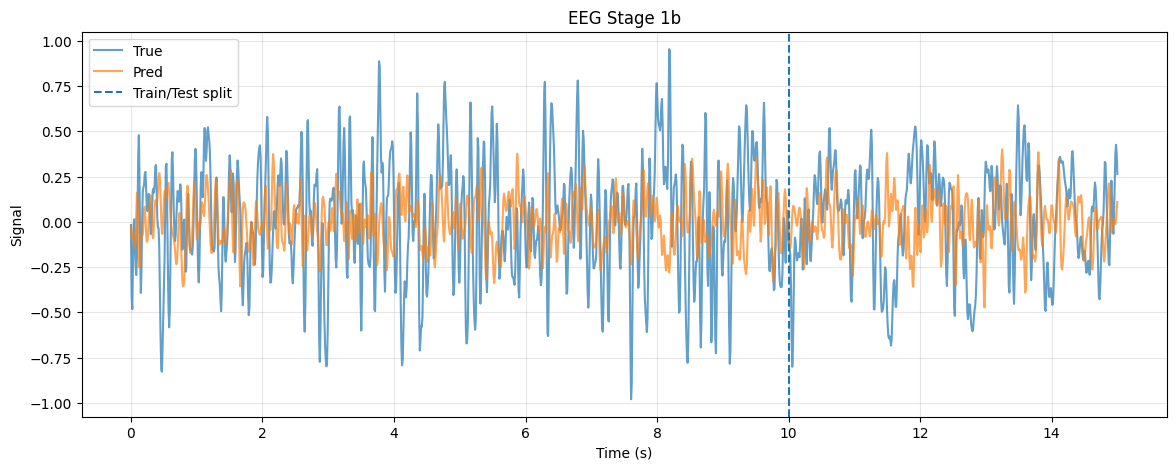


=== eeg_stage2 vs eeg_true ===
Full  Corr: 0.1785
Train Corr: 0.2525
Test  Corr: 0.0025


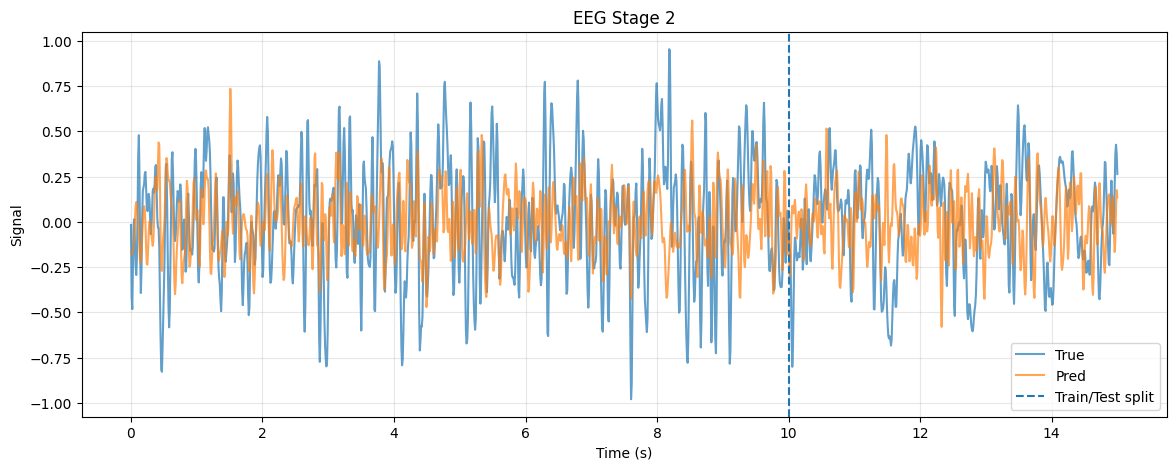


=== ecg_stage2 vs ecg_true ===
Full  Corr: 0.4763
Train Corr: 0.9677
Test  Corr: -0.0123


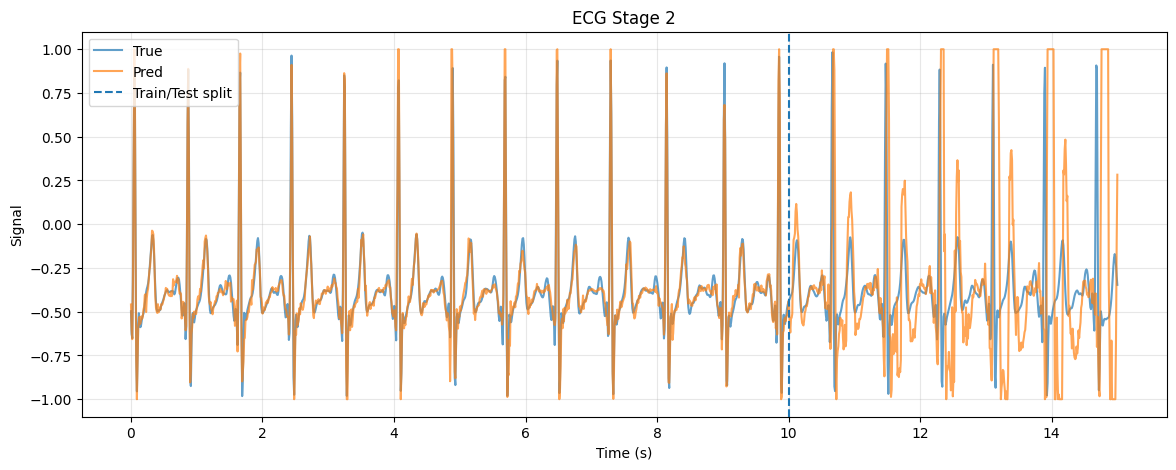


=== ecg_stage4 vs ecg_true ===
Full  Corr: 0.4701
Train Corr: 0.9398
Test  Corr: -0.0088


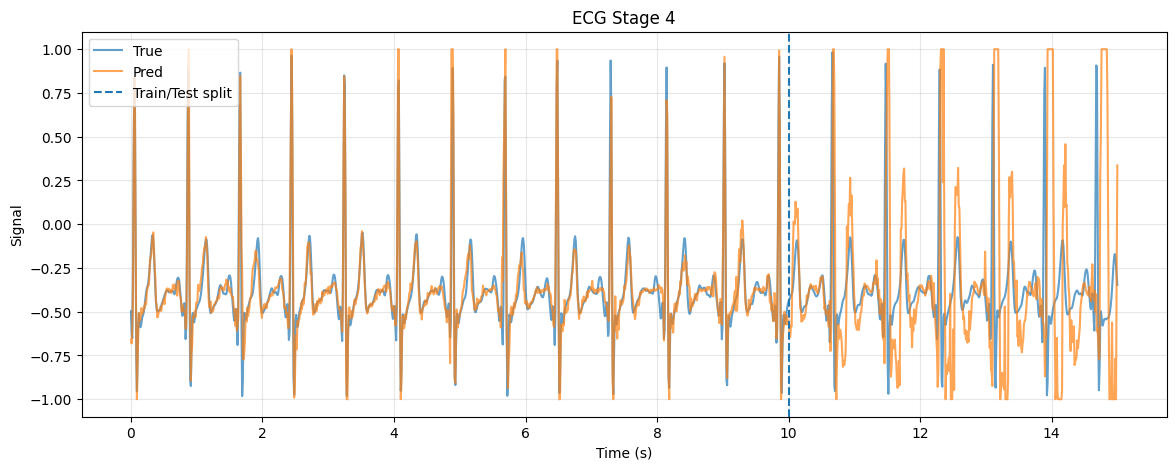

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def compute_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    return np.sum(x * y) / (np.sqrt(np.sum(x**2) * np.sum(y**2)) + 1e-8)


def plot_signal(region_dir, true_name, pred_name, title=None):
    # Load
    true_full = np.load(f"{region_dir}/{true_name}_full.npy")
    pred_full = np.load(f"{region_dir}/{pred_name}_full.npy")

    true_train = np.load(f"{region_dir}/{true_name}_train.npy")
    pred_train = np.load(f"{region_dir}/{pred_name}_train.npy")

    true_test = np.load(f"{region_dir}/{true_name}_test.npy")
    pred_test = np.load(f"{region_dir}/{pred_name}_test.npy")

    # Correlations
    corr_full = compute_corr(pred_full, true_full)
    corr_train = compute_corr(pred_train, true_train)
    corr_test = compute_corr(pred_test, true_test)

    print(f"\n=== {pred_name} vs {true_name} ===")
    print(f"Full  Corr: {corr_full:.4f}")
    print(f"Train Corr: {corr_train:.4f}")
    print(f"Test  Corr: {corr_test:.4f}")

    # Time axis
    T = len(true_full)
    t = np.linspace(0, T/100, T)  # assuming fs_model=100

    T_train = len(true_train)

    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(t, true_full, label="True", alpha=0.7)
    plt.plot(t, pred_full, label="Pred", alpha=0.7)

    plt.axvline(t[T_train], linestyle="--", label="Train/Test split")

    plt.title(title if title else f"{pred_name} vs {true_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

region_dir = "/home/shobs/Desktop/DDP/multi_region_results/region_11"

# EEG
plot_signal(region_dir, "eeg_true", "eeg_stage1b", title="EEG Stage 1b")
plot_signal(region_dir, "eeg_true", "eeg_stage2", title="EEG Stage 2")

# ECG
plot_signal(region_dir, "ecg_true", "ecg_stage2", title="ECG Stage 2")
plot_signal(region_dir, "ecg_true", "ecg_stage4", title="ECG Stage 4")